# Titanic Feature Engineering — Corrected Notebook

Same use case and same overall pipeline design (ColumnTransformer with OHE / scaler /
custom FunctionTransformer / categorical encoder / passthrough, then pickled) as your
original notebook — but with the missing-value handling, encoder choice, and fit/pickle
order fixed.

A synthetic Titanic-shaped dataset is generated below so this runs standalone. Swap the
load cell for `pd.read_csv("titanic.csv")` to use the real file.

See **"What was wrong in the original notebook"** at the bottom for the mapping back to
your file.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")

## 2. Load data

Swap for `pd.read_csv("titanic.csv")` for the real file. The synthetic version below
includes missing `Age` and `Embarked` values (like the real dataset) and a handful of very
high `Fare` outliers, since those are exactly the details the original notebook's pipeline
never accounted for.

In [2]:
pd.read_csv("titanic.csv")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [3]:
rng = np.random.default_rng(7)
n = 891

data = pd.DataFrame({
    "PassengerId": np.arange(1, n + 1),
    "Survived": rng.choice([0, 1], size=n, p=[0.62, 0.38]),
    "Pclass": rng.choice([1, 2, 3], size=n, p=[0.24, 0.21, 0.55]),
    "Name": [f"Passenger, Mr. {i}" for i in range(n)],
    "Sex": rng.choice(["male", "female"], size=n, p=[0.65, 0.35]),
    "Age": rng.normal(29, 14, size=n).round(1).clip(0.4, 80),
    "SibSp": rng.choice([0, 1, 2, 3, 4], size=n, p=[0.68, 0.23, 0.05, 0.02, 0.02]),
    "Parch": rng.choice([0, 1, 2, 3], size=n, p=[0.76, 0.13, 0.08, 0.03]),
    "Ticket": [f"T{i}" for i in range(n)],
    "Fare": rng.gamma(2.0, 15, size=n).round(2),
    "Cabin": [None] * n,
    "Embarked": rng.choice(["S", "C", "Q"], size=n, p=[0.72, 0.19, 0.09]),
})

# Titanic-realistic missingness: ~20% of Age, a couple of Embarked
data.loc[data.sample(int(n * 0.20), random_state=1).index, "Age"] = np.nan
data.loc[data.sample(2, random_state=2).index, "Embarked"] = np.nan

# Titanic-realistic Fare outliers (a few passengers paid 4-10x the norm)
data.loc[data.sample(5, random_state=3).index, "Fare"] = rng.uniform(200, 512, size=5).round(2)

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,3,"Passenger, Mr. 0",male,40.7,0,0,T0,13.47,None,S
1,2,1,2,"Passenger, Mr. 1",male,11.5,0,0,T1,18.12,None,S
2,3,1,2,"Passenger, Mr. 2",female,NaN,0,0,T2,10.96,None,Q
3,4,0,1,"Passenger, Mr. 3",male,NaN,0,0,T3,18.27,None,S
4,5,0,3,"Passenger, Mr. 4",male,13.5,0,0,T4,9.71,None,S


# Basic checks

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          713 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        0 non-null      object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            178
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          891
Embarked         2
dtype: int64

### Drop columns that don't carry predictive signal

Same drop as your original — `Ticket`, `PassengerId`, `Name`, `Cabin` — this part was fine.

In [6]:
data = data.drop(columns=["Ticket", "PassengerId", "Name", "Cabin"])
data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

## 3. Handle missing values — the step that was missing entirely

`.info()` above shows `Age` and `Embarked` have missing values (in the real dataset, ~20%
of `Age` and 2 rows of `Embarked`). The original notebook never checked or fixed this — it
went straight from "basic checks" to building the `ColumnTransformer`. That doesn't crash,
but it doesn't work correctly either:

- `LabelEncoder`/`OneHotEncoder` **don't error on `NaN`** — they silently create a brand-new
  "nan" category, so missing `Embarked` values would have been treated as if "not embarking
  anywhere" were a real, meaningful category, rather than being imputed.
- `FunctionTransformer(divide_by_100)` on a missing `Age` just returns `NaN`, which then
  flows straight into a model that likely can't handle it.

Fix: impute before encoding — `Age` (continuous, right-skewed by a long tail of older
passengers) with the **median**, `Embarked` (categorical, 3 levels) with the **mode**.

In [7]:
data["Age"] = data["Age"].fillna(data["Age"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
data.isnull().sum()   # should all be zero now

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

# Checking for outliers

## What is an outlier?

- An outlier is an observation that lies an abnormal distance from other values in a
  random sample from a population.
- It's up to the analyst (or a consensus process) to decide what counts as "abnormal."

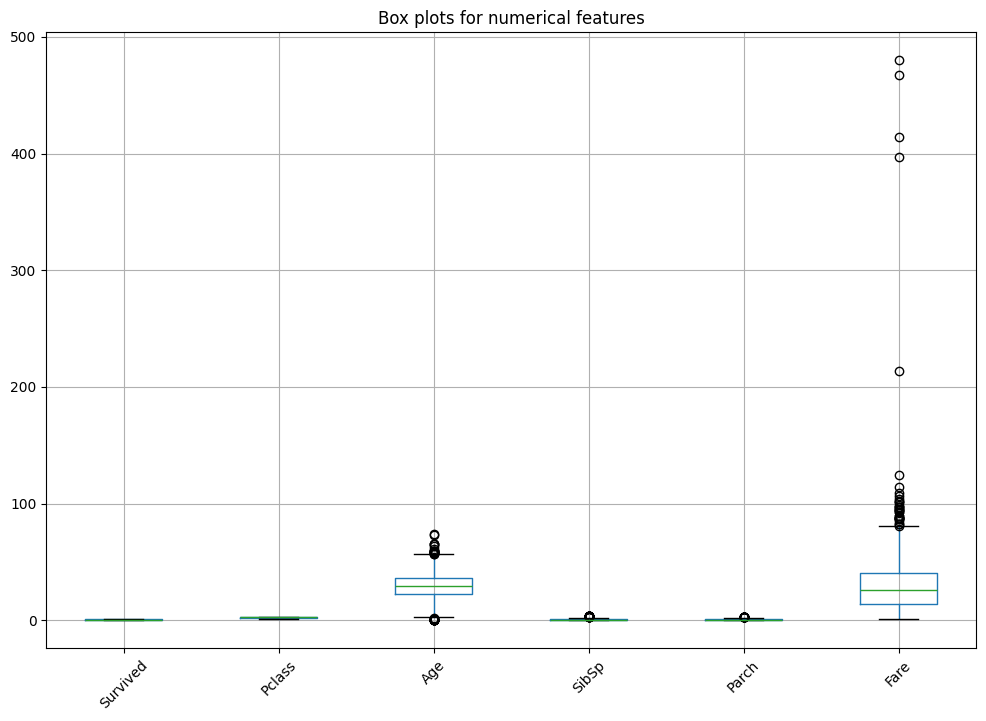

In [8]:
numerical_cols = data.select_dtypes(include=["int", "float"]).columns
plt.figure(figsize=(12, 8))
data[numerical_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Box plots for numerical features")
plt.show()

### Treating the Fare outliers

The original notebook showed the boxplots, defined what an outlier is, and then **never
actually treated any of them** — `Fare` clearly has extreme values in the plot above, but
nothing downstream capped or removed them; they went straight into `StandardScaler`
untouched, which is exactly the kind of feature `StandardScaler` is most distorted by
(it uses mean/variance, both of which outliers inflate). Capping with IQR fences, like your
Loan notebook did, fixes this.

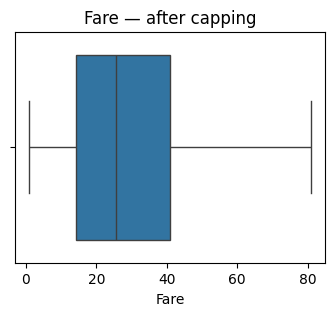

In [9]:
q1, q3 = data["Fare"].quantile(0.25), data["Fare"].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
data["Fare"] = data["Fare"].clip(lower, upper)

plt.figure(figsize=(4, 3))
sns.boxplot(x=data["Fare"], orient="h")
plt.title("Fare — after capping")
plt.show()

# EDA

In [10]:
data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.375982,2.312009,29.355892,0.380471,0.423120,29.855289
std,0.484647,0.823299,12.368798,0.767324,0.787175,20.377110
min,0.000000,1.000000,0.400000,0.000000,0.000000,0.860000
25%,0.000000,2.000000,22.350000,0.000000,0.000000,14.105000
50%,0.000000,3.000000,29.400000,0.000000,0.000000,25.530000
75%,1.000000,3.000000,36.100000,1.000000,1.000000,40.830000
max,1.000000,3.000000,73.700000,4.000000,3.000000,80.917500


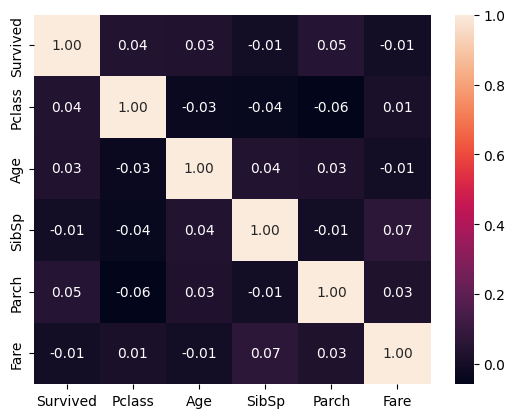

In [11]:
sns.heatmap(data.select_dtypes(include=["int", "float"]).corr(), annot=True, fmt=".2f")
plt.show()

# Data preprocessing

### Separate the target before building any feature transformer

The original notebook put `Survived` inside the **same `ColumnTransformer`** as the real
features, as one of the "pass-through" columns. Mixing `X` and `y` into one transformer is
an anti-pattern: the target isn't a feature, and bundling it in means every future user of
the pickled preprocessor has to remember to strip it back out again (and risks it leaking
into training if forgotten). Split it out here, before any encoding/scaling.

In [12]:
X = data.drop(columns=["Survived"])
Y = data["Survived"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

## Choosing an encoder for `Embarked`

Your own markdown said: *"Label encoding is suitable for categorical features with only two
distinct categories."* `Embarked` has **three** (`S`, `C`, `Q`) — by your own stated rule,
`LabelEncoder` shouldn't have been used on it. It's also worth knowing that scikit-learn's
`LabelEncoder` is documented as a tool for encoding the **target** column, not a feature
inside a `ColumnTransformer` — that's why it needed the `ModifiedLabelEncoder` reshape hack
in the first place. For an unordered, multi-category feature like `Embarked`, one-hot
encoding it (same technique already correctly used for `Sex`) is the right tool — no custom
subclass needed.

In [13]:
def divide_by_100(x):
    return x / 100

custom = FunctionTransformer(divide_by_100)

def same(x):
    return x

no_trans = FunctionTransformer(same)

In [14]:
OHE_columns = ["Sex", "Embarked"]
standard_scaler_columns = ["Fare"]
function_transformer_columns = ["Age"]
passthrough_columns = ["Pclass", "SibSp", "Parch"]   # Survived removed — it's the target, not a feature

preprocessor = ColumnTransformer([
    ("OHE_columns", OneHotEncoder(drop="first", handle_unknown="ignore"), OHE_columns),
    ("standard_scaler", StandardScaler(), standard_scaler_columns),
    ("custom", custom, function_transformer_columns),
    ("pass_through", no_trans, passthrough_columns),
])
preprocessor

,transformers,"[('OHE_columns', ...), ('standard_scaler', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


Note `drop="first"` on the `OneHotEncoder`: with `Sex` having only 2 categories, one-hot
encoding both creates two perfectly redundant columns (a "dummy variable trap") — dropping
the first category keeps just the non-redundant one. `handle_unknown="ignore"` protects
against a category showing up at inference time that wasn't seen during `fit` (e.g. a typo
or a rare `Embarked` value), instead of raising an error in production.

## Fit the preprocessor before pickling it

This is the step that was missing entirely from the original notebook: it built the
`ColumnTransformer`, then went **straight to `pickle.dump`** without ever calling `.fit(...)`
on it. An unfit `ColumnTransformer` pickles without complaint, but it's useless — calling
`.transform()` on it after unpickling raises `NotFittedError`, since it has no learned
means/variances/categories yet. Fit it on the training data first (never on test data —
that would leak test-set statistics into the encoder/scaler), then pickle the *fitted*
object.

In [15]:
preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

X_train_transformed[:5]

array([[ 0.        ,  0.        ,  0.        , -1.00496596,  0.255     ,
         2.        ,  0.        ,  0.        ],
       [ 1.        ,  0.        ,  1.        ,  0.02934254,  0.271     ,
         2.        ,  2.        ,  0.        ],
       [ 0.        ,  0.        ,  1.        , -0.28010426,  0.294     ,
         1.        ,  1.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  1.93328607,  0.184     ,
         1.        ,  0.        ,  0.        ],
       [ 1.        ,  0.        ,  1.        ,  2.54509024,  0.369     ,
         2.        ,  0.        ,  1.        ]])

# Creating pickle file

In [16]:
with open("Titanic.pkl", "wb") as file:
    pickle.dump(preprocessor, file)

In [17]:
with open("Titanic.pkl", "rb") as file:
    pre = pickle.load(file)

# this now works immediately, because the object we pickled was already fitted
pre.transform(X_test)[:5]

array([[ 1.        ,  0.        ,  1.        , -0.99700591,  0.449     ,
         3.        ,  0.        ,  0.        ],
       [ 0.        ,  1.        ,  0.        ,  0.88952502,  0.202     ,
         3.        ,  0.        ,  1.        ],
       [ 1.        ,  0.        ,  1.        , -1.19252454,  0.365     ,
         3.        ,  2.        ,  0.        ],
       [ 0.        ,  0.        ,  1.        ,  0.28058149,  0.382     ,
         1.        ,  1.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , -0.81292984,  0.278     ,
         3.        ,  0.        ,  0.        ]])

## What was wrong in the original notebook — quick-reference list

| # | Section | What was wrong | Fix used above |
|---|---|---|---|
| 1 | Basic checks → Data preprocessing | `Age` (~20% missing) and `Embarked` (2 missing) were never imputed anywhere — the notebook goes from `.info()`/`.describe()` straight to building the `ColumnTransformer` | Median-impute `Age`, mode-impute `Embarked` before any encoding |
| 2 | (silent consequence of #1) | `LabelEncoder`/`OneHotEncoder` don't error on `NaN` — they silently create a bogus `"nan"` category instead of raising a warning, so the missing values were being treated as a real, meaningful category rather than flagged | Resolved once missing values are imputed first |
| 3 | Checking for outliers | Boxplots were drawn and outliers were defined conceptually, but **no outlier treatment was ever applied** — `Fare`'s extreme values went straight into `StandardScaler` untouched | IQR-based capping on `Fare` before scaling |
| 4 | Using Label Encoder here → Embarked | The markdown itself states label encoding is for features with **only two** categories, then uses it on `Embarked`, which has **three** (`S`/`C`/`Q`) — contradicts its own stated rule. `LabelEncoder` is also documented as a tool for the target `y`, not a feature column (hence needing the `ModifiedLabelEncoder` reshape hack to force it into a `ColumnTransformer`) | One-hot encode `Embarked`, same as `Sex` — no custom subclass needed |
| 5 | Using Label Encoder here → Embarked (markdown) | The worked example describes an *ordinal* case ("Small/Medium/Large") to explain label encoding, but plain `LabelEncoder` does **not** preserve a chosen order — it assigns integers by sort order/first appearance, not by intended rank. That description doesn't match what the code actually does | If true ordinal order is ever needed, use `OrdinalEncoder(categories=[[...]])` instead |
| 6 | Defining the preprocessor | `Survived` (the target) was included as a `"Pass_through"` column **inside** the feature `ColumnTransformer`, mixing `X` and `y` together | Split `X`/`Y` with `train_test_split` first; `Survived` isn't part of the transformer at all |
| 7 | Defining the preprocessor / Creating pickle file | The `ColumnTransformer` was **never fit** on any data — it went directly from construction to `pickle.dump`. Unpickling it and calling `.transform()` would raise `NotFittedError` | `preprocessor.fit(X_train)` before pickling; pickle the fitted object |
| 8 | Using One Hot Encoder here → Sex | One-hot encoding a 2-category column with no `drop` creates two perfectly redundant columns (dummy variable trap) | `OneHotEncoder(drop="first", handle_unknown="ignore")` |